# Модель предсказания массы морских черепах

* *Автор: Романов  Артём*
* *Дата: 19.04.2026*

- Придумайте тетрадке заголовок, который хорошо описывает решаемую задачу.
- Кратко, но понятно опишите решаемую задачу.

Задача состоит в разработке модели линейной регрессии, которая будет использовать габариты и другие данные от TurtleCV для предсказания массы черепах.

## Постановка задачи машинного обучения

- Опишите, какую задачу нужно решить: регрессии или классификации.
- Выберите поле, которое станет целевой переменной.
- Назовите метрики качества модели, которые планируете использовать.
- Опишите критерии успешности проекта с опорой на метрики.

Необходимо решить задачу регрессии с линейной моделью, где целевая переменная — масса черепах. Основная метрика качества — MAE, допустимое значение которой не превышает 5 кг. Дополнительно используются MSE, MAPE и R², причём для лучшей модели значение R² должно быть не ниже 0.97 на валидационной и тестовой выборках.

## Подключение и настройка библиотек

В блоке кода ниже, помимо уже указанных библиотек, импортируйте все остальные, которые планируете использовать для проекта.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 0

## Загрузка датасета

- Загрузите данные из файла `turtles.csv`, путь к файлу: `'/datasets/turtles.csv'`. При использовании метода [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) установите правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет — что нужно сделать, чтобы устранить препятствия?

Загрузим данные для дальнейшей работы из файла `turtles.csv`. Установим правильные значения для параметров `sep` и `decimial`: `\t` и `;` соответственно

In [2]:
# Загрузка датафрейма
df = pd.read_csv('turtles.csv', sep='\t', decimal=',')

# Проверяем корректность отображения датафрейма
df.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


Данные соответствуют описанию, за исключением некорректного отображения названия признака `registration number`, название не соответствует стилю **shake_case**. Исправим это:

In [3]:
df.rename(columns={'registration number': 'registration_number'}, inplace=True)

Выведем общие сведения о данных:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration_number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

Заметим, что название признака соответствует стилю **shake_case**.

Также заметим, что изначальный датасет содержит 8861 запись черепах. Среди признаков у нас 8 признаков имеют тип `int`, 10 признаков содержат тип `float` и 2 признака имеют тип `object`. Некоторые признаки обладают пропусками, которые предстоит обработать. Признак `shell_crack` не соответствует изначальному типу, в дальнейшем займёмся корректированием. Признаки типа `float`и `int` также требудет дополнительной оптимизации памяти, необходимо будет каждому признаку подобрать минимально числовой тип.

## Исследовательский анализ данных

Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

##### 4.1 Выясняем данные о черепахах

Посмотрим, какие данные о каких видах черепах представены в датасете:

In [5]:
df['binomial_name'].value_counts()

binomial_name
Lepidochelys olivacea     3372
Chelonia mydas            2325
Caretta caretta            674
lepidochelys olivacea      416
Dermochelys coriacea       399
Eretmochelys imbricata     332
Lepidochelys Olivacea      285
chelonia mydas             252
Chelonia Mydas             177
LEPIDOCHELYS OLIVACEA      142
caretta caretta             90
CHELONIA MYDAS              75
Caretta Caretta             46
eretmochelys imbricata      41
dermochelys coriacea        40
CARETTA CARETTA             37
Eretmochelys Imbricata      28
Dermochelys Coriacea        27
Lepidochelys kempii         22
DERMOCHELYS CORIACEA        18
ERETMOCHELYS IMBRICATA       8
lepidochelys kempii          3
Lepidochelys Kempii          3
Name: count, dtype: int64

Данные внутри признака ненормализованы, из-за этого затруднительно сделать вывод о видах черепах. Нормализцем данные, приведя их к типу **shake_case**:

In [6]:
df['binomial_name'] = df['binomial_name'].str.lower().str.replace(' ', '_')

In [7]:
df['binomial_name'].value_counts()

binomial_name
lepidochelys_olivacea     4215
chelonia_mydas            2829
caretta_caretta            847
dermochelys_coriacea       484
eretmochelys_imbricata     409
lepidochelys_kempii         28
Name: count, dtype: int64

Данные нормализованы, и теперь мы видим, что в датасете присутствует информация о 6 видах черепах (есть также записи о черепахах, где название вида не указано). Для дальшейней работы нам необходимы черепах вида *Chelonia mydas*. Создадим копию датасета только с этим видом:

##### 4.2 Отбор необходимых записей

In [8]:
data = df[df['binomial_name'] == 'chelonia_mydas'].copy()

In [9]:
data.shape

(2829, 20)

Копия датасета содержит только записи о виде *Chelonia mydas*. Сортировка прошла успешно

##### 4.3 Удаление ненужных признаков и обработка пропусков

Посмотрим на общую информацию скопированного датасета:

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2829 entries, 8 to 8859
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2829 non-null   int64  
 1   binomial_name        2829 non-null   object 
 2   registration_number  2825 non-null   object 
 3   shell_length         2794 non-null   float64
 4   shell_width          2829 non-null   int64  
 5   head_length          2790 non-null   float64
 6   head_width           2790 non-null   float64
 7   flipper_length_1     2829 non-null   int64  
 8   flipper_width_1      2829 non-null   int64  
 9   flipper_length_2     2829 non-null   int64  
 10  flipper_width_2      2829 non-null   int64  
 11  flipper_length_3     2798 non-null   float64
 12  flipper_width_3      2798 non-null   float64
 13  flipper_length_4     2798 non-null   float64
 14  flipper_width_4      2798 non-null   float64
 15  circle_count         2829 non-null   int64 

Можно заметить, что в целевой прееменной присутствуют пропуски. Их немного, но заполнение какой-либой переменной может исказить результат моделей и качество метрики. Удалим наблюдения, в которых есть пропуск в `weight`:

In [11]:
data.dropna(subset=['weight'], inplace=True)

In [12]:
data = data[data['weight'] > 0]

В дальнейшем, для работы с регрессией, нам будут нужны только числовые признаки. `binomial_name` и `registration_number` не несут в себе особого смысла - все черепахи у нас одного вида, а регистрационный номер черепахи не играет роли в регирессии, так как данные сложно интерпитировать, они записаны в виде букв и цифр. `id` также необходимо удалить, так как он не несёт в себе полезной информации. `timestamp` также необходимо удалить, так как перед нами стоит задача предсказания веса, поэтому время для пердсказания нам не потребуется

Сначала удалим только `binomial_name`, так как оставшиеся признаки будут необходимы нам для выявления дубликатов

In [13]:
data.drop('binomial_name', axis=1, inplace=True)

In [14]:
data.shape

(2823, 19)

##### 4.4 Проверка данных на дубликаты

Проверим данные на явные дубликаты:

In [15]:
data.duplicated().sum()

np.int64(340)

В датасете оказалось 341 явный дубликат. Удалим их, изменения сохраним в датасете, с которым сейчас работаем:

In [16]:
data.drop_duplicates(inplace=True)

Также проверим данные на неявные думбликаты: по `id` и `registration_number`:

In [17]:
data.duplicated('id').sum()

np.int64(0)

In [18]:
data.duplicated('registration_number').sum()

np.int64(3)

В результате, при анализе признака `registration_number` были обнаружены дубликаты. Удалим их

In [19]:
# Удаляем дубли по номеру, оставляя первое измерение
data.drop_duplicates(subset=['registration_number'], keep='first', inplace=True)

Удалим оставшиеся признаки, которые нем не пригодятся в решении задачи

In [20]:
data.drop(['id', 'registration_number', 'timestamp'], axis=1, inplace=True)

In [21]:
data.shape

(2480, 16)

В итоге из датасета были удалены признаки, которые не пригодятся для дальнейшей работы, а также были удалены явные и неявные дубликаты в данных

##### 4.5 Визуализация оставшихся признаков и их обработка

Проанализируем распределение признаков, оценим выбросы и определим, есть ли критичные выбросы.

Напишем простые функции для гистограммы и диаграммы размаха. В качестве параметра необходимо передать название колонки

In [22]:
# Функция для построения boxplot
def make_boxplot(col, showfliers=True, title=None, xlabel=None):
    ax = data.boxplot(col, vert=False, showfliers=showfliers, figsize=(9, 6))
    
    # Добавление заголовка
    if title is None:
        ax.set_title(f'Boxplot of {col}', fontsize=14)
    else:
        ax.set_title(title, fontsize=14)
    
    # Добавление подписей осей
    if xlabel:
        ax.set_xlabel(xlabel)
    else:
        ax.set_xlabel('Values')
    
    return ax

# Функция для построения гистограммы
def make_hist(col, title=None, xlabel=None, ylabel=None, bins=30, color='blue'):
    ax = data[col].plot(kind='hist', color=color, bins=bins, figsize=(9, 6))
    
    # Добавление заголовка
    if title is None:
        ax.set_title(f'Histogram of {col}', fontsize=14)
    else:
        ax.set_title(title, fontsize=14)
    
    # Добавление подписей осей
    if xlabel:
        ax.set_xlabel(xlabel)
    else:
        ax.set_xlabel(col)
    
    if ylabel:
        ax.set_ylabel(ylabel)
    else:
        ax.set_ylabel('Frequency')
    
    return ax

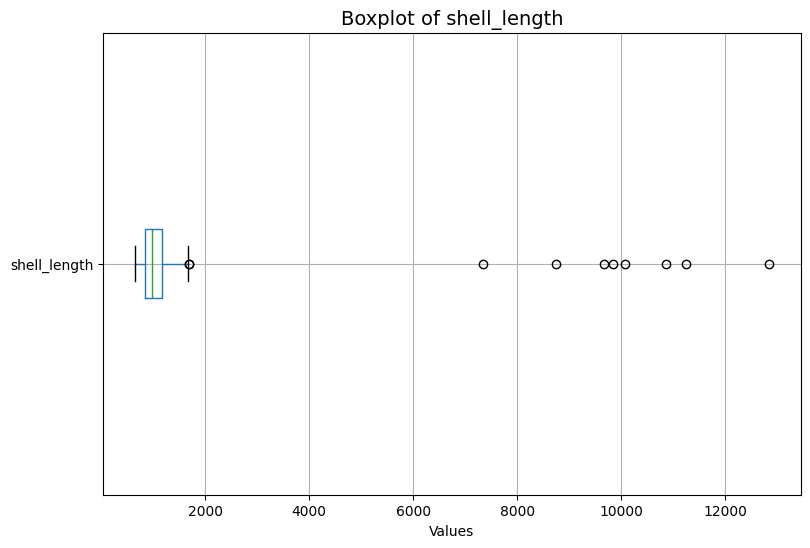

In [23]:
make_boxplot('shell_length')
plt.show()

Можно заметить что в данных присутствуют большие выбросы, которые не соответствуют реальным данным. Можно предположить, что такие выбросы возникли из-за случайного уможения на 10 данных, которые уже были указаны в миллиметрах. Если у последующих признаков буудт выбросы, превышающие максимальное значение, будем предполагать аналогичную ошибку и исправлять её


Напишем простую функцию, которая корректирует данные, и сразу же визуализирует их на диаграмме размаха:

In [24]:
# Исправляем выбросы
data['shell_length'] = data['shell_length'].apply(lambda x: x/10 if x > 1530 else x)

Применим фукнцию к `shell_length` 

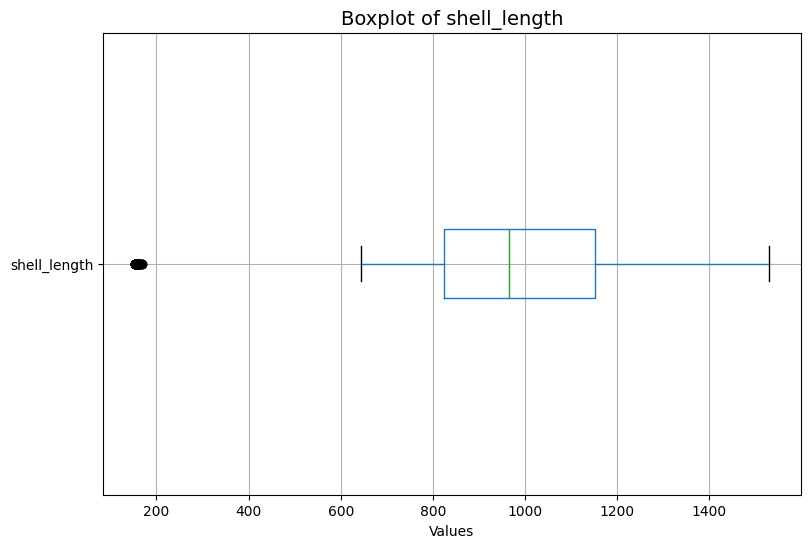

In [25]:
make_boxplot('shell_length')
plt.show()

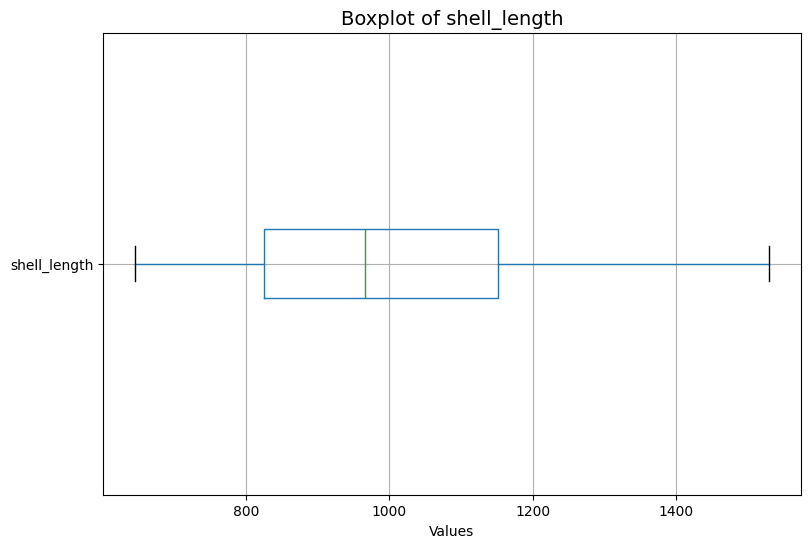

In [26]:
make_boxplot('shell_length', showfliers=False)
plt.show()

Теперь данные похожи на правду. Большинство данных сконцентрированно в промежутке от 60 до 170 мм с небольшим количеством выбросов до 1300 мм. Сейчас выбросы не являются критичными и не требуют дальнейшей сортировки

Визуализируем диаграмму размаха `shell_width`:

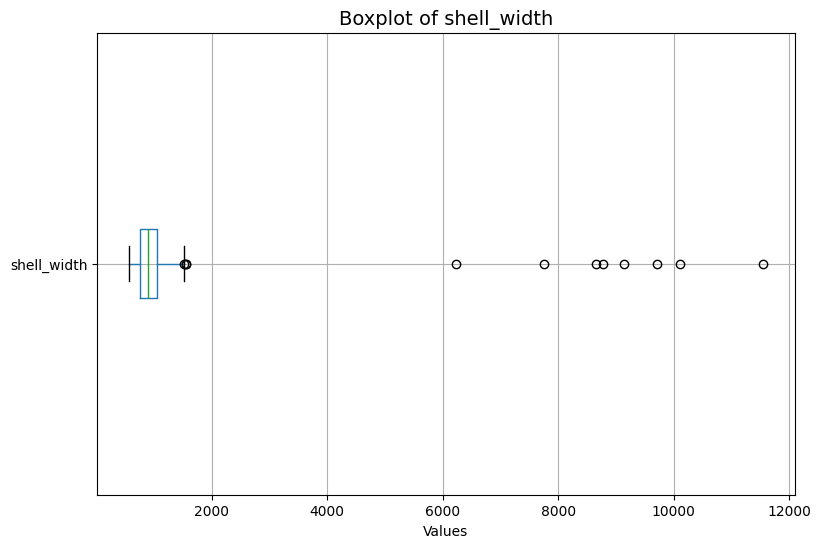

In [27]:
make_boxplot('shell_width')
plt.show()

Заметны экстремальные выбросы, возможно начальныке данные также были умножены на 10. Применим функцию `cor_data_and_make_boxplot` для корректировки данных и визуализации новой диаграммы размаха:

In [28]:
data['shell_width'] = data['shell_width'].apply(lambda x: x/10 if x > 1320 else x)

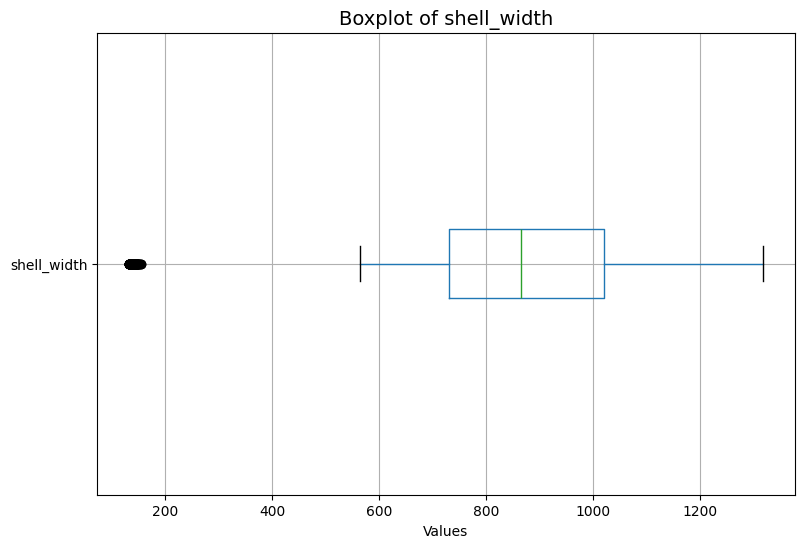

In [29]:
make_boxplot('shell_width')
plt.show()

Теперь данные выглядят реалистично, продолжим анализ остальных признаков.

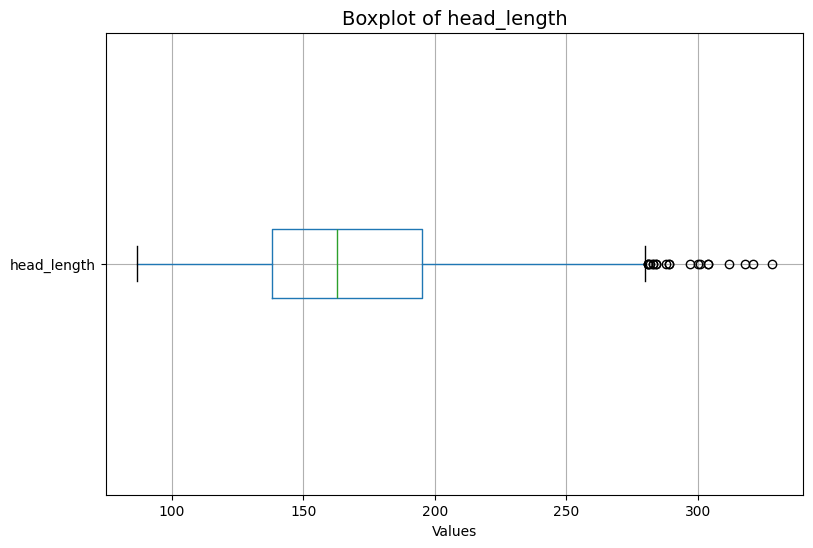

In [30]:
make_boxplot('head_length')
plt.show()

Выбросы — биологически нормальные крупные особи, их удаление ухудшит модель для взрослых черепах. Предобработка не мужна

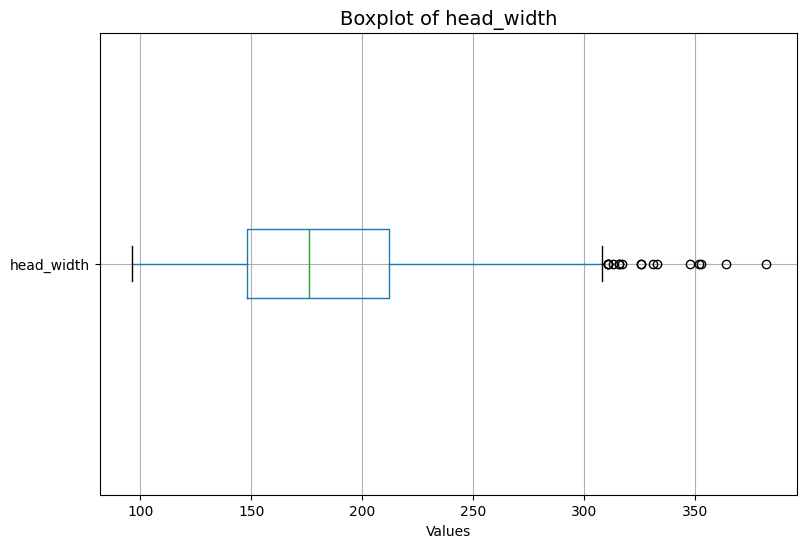

In [31]:
make_boxplot('head_width')
plt.show()

Аналогично с `head_length`, дополнительная обработка не нужна, она только ухудшит модель

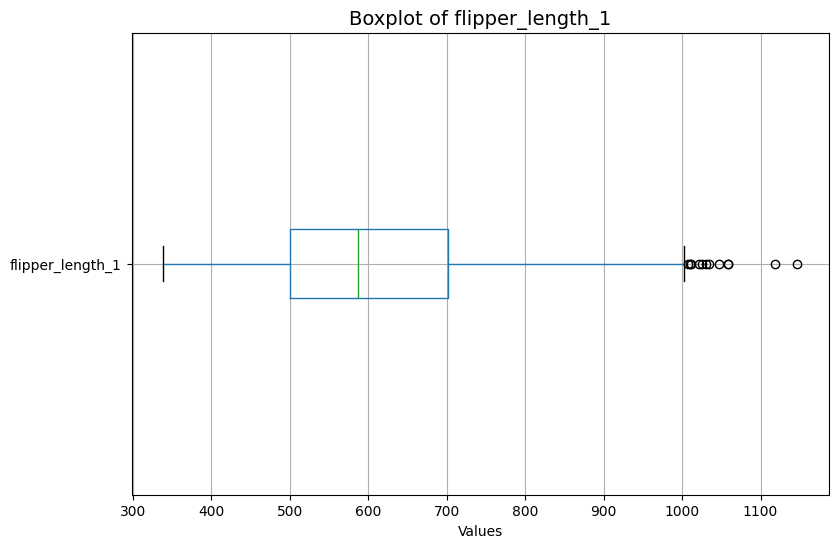

In [32]:
make_boxplot('flipper_length_1')
plt.show()

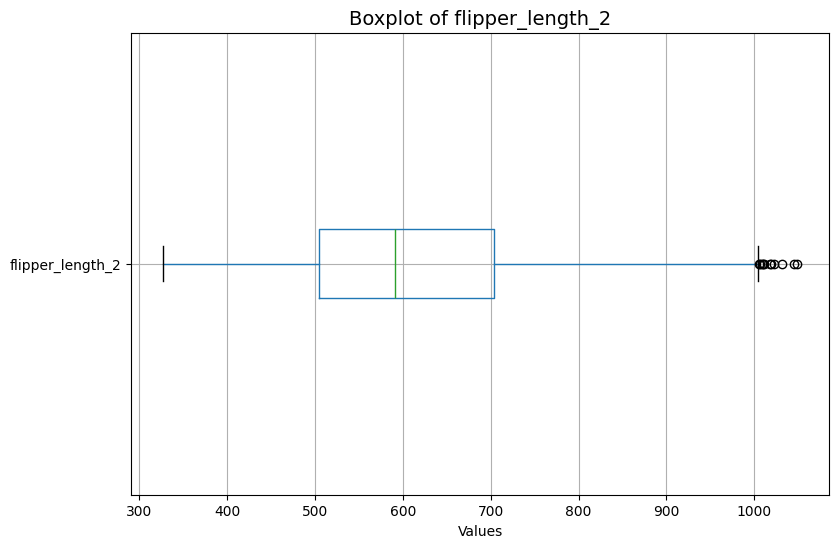

In [33]:
make_boxplot('flipper_length_2')
plt.show()

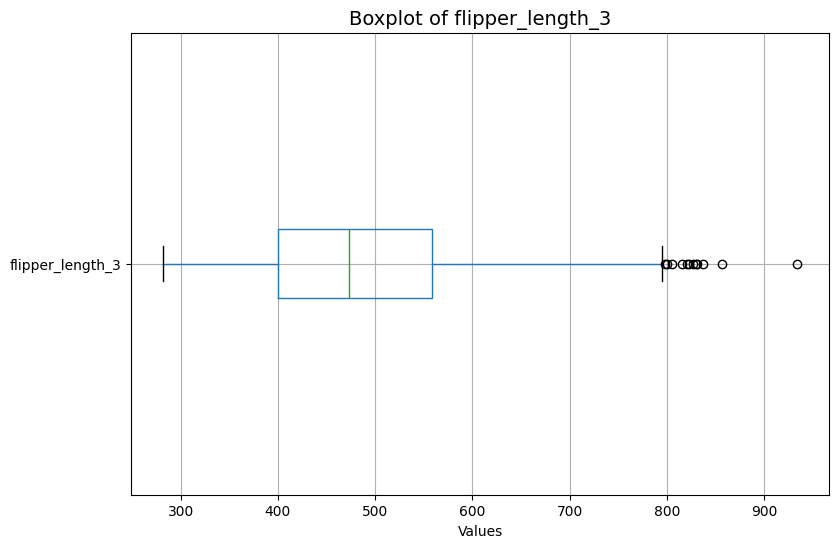

In [34]:
make_boxplot('flipper_length_3')
plt.show()

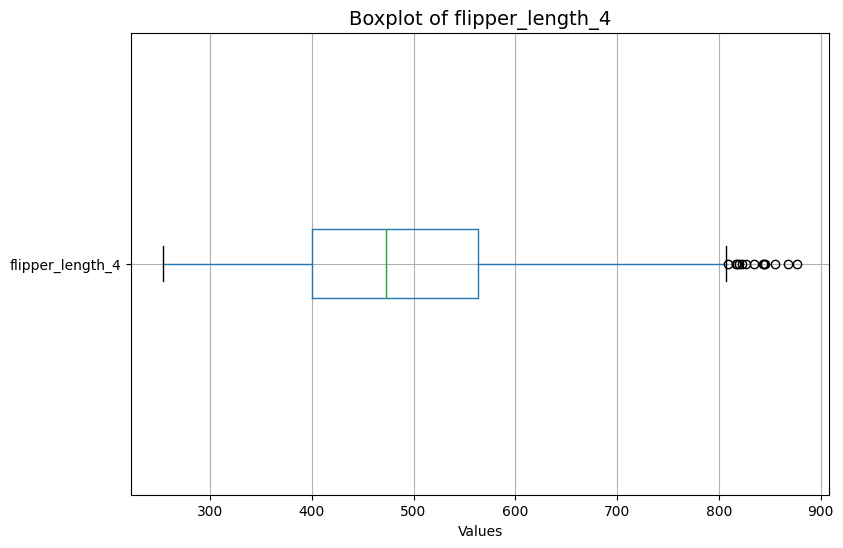

In [35]:
make_boxplot('flipper_length_4')
plt.show()

Диаграммы размаха, содержащие информацию о длине одной ласты черепахи, имеют выбросы, но они не являются критичными, и дополнительной обработки не требуют

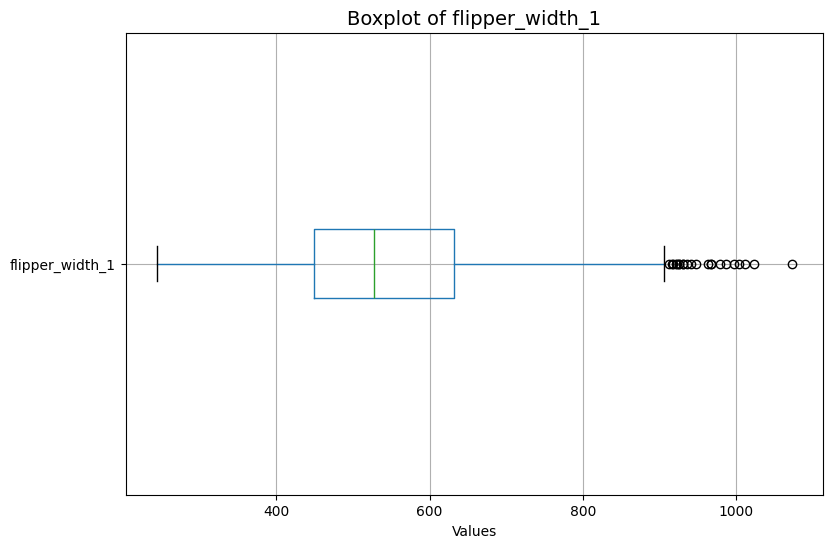

In [36]:
make_boxplot('flipper_width_1')
plt.show()

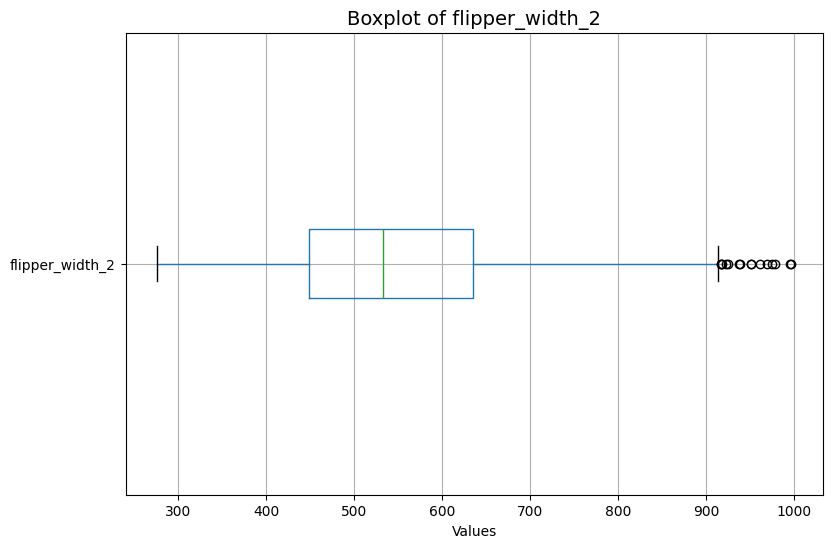

In [37]:
make_boxplot('flipper_width_2')
plt.show()

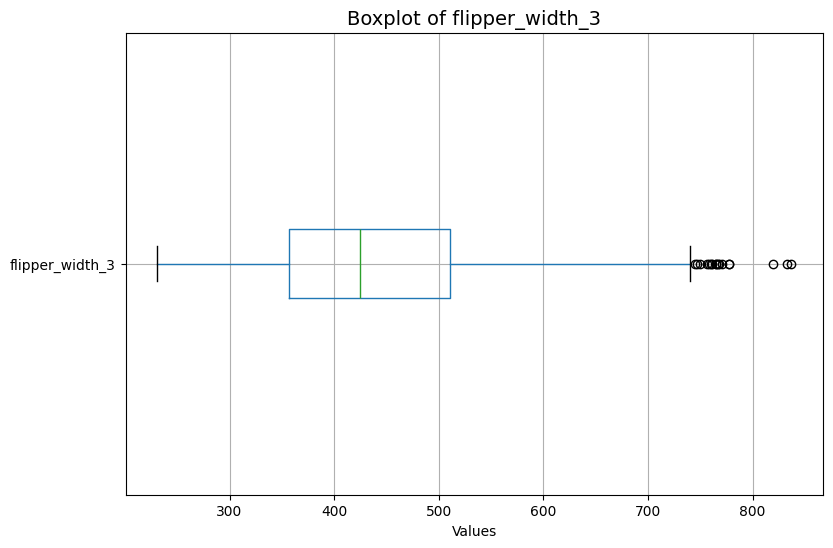

In [38]:
make_boxplot('flipper_width_3')
plt.show()

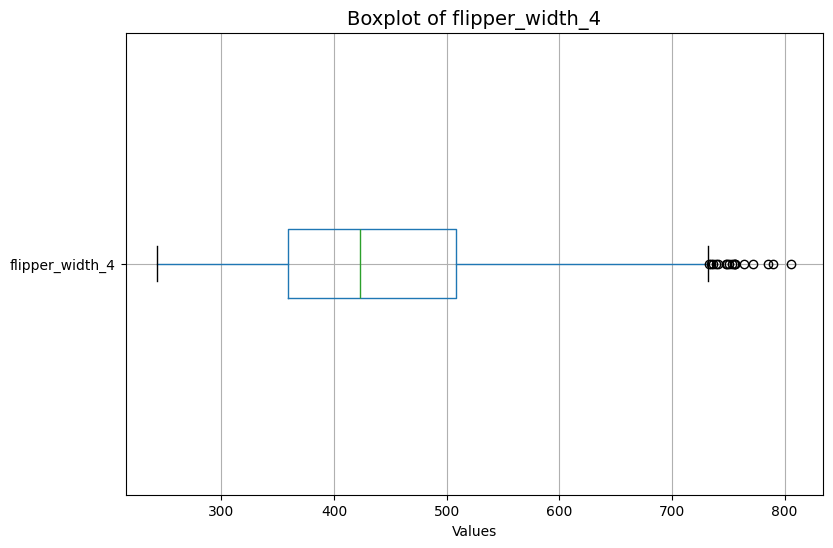

In [39]:
make_boxplot('flipper_width_4')
plt.show()

Диаграммы размаха о ширине одной ласты черепахи также не вызывают вопросы. Выбросы не экстремальные, дополнительная обработка не требуется

Для количеста колец роста на панцире черепахи, визуализируем диаграмму размаха и гистограмму:

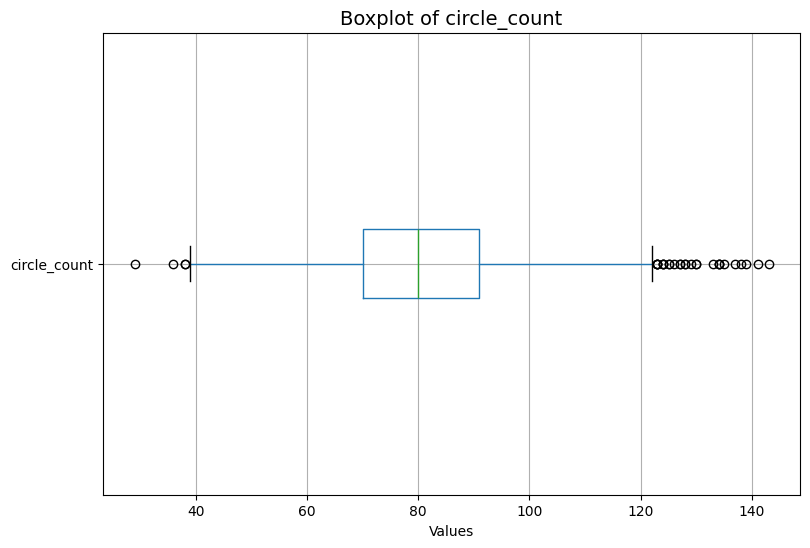

In [40]:
make_boxplot('circle_count')
plt.show()

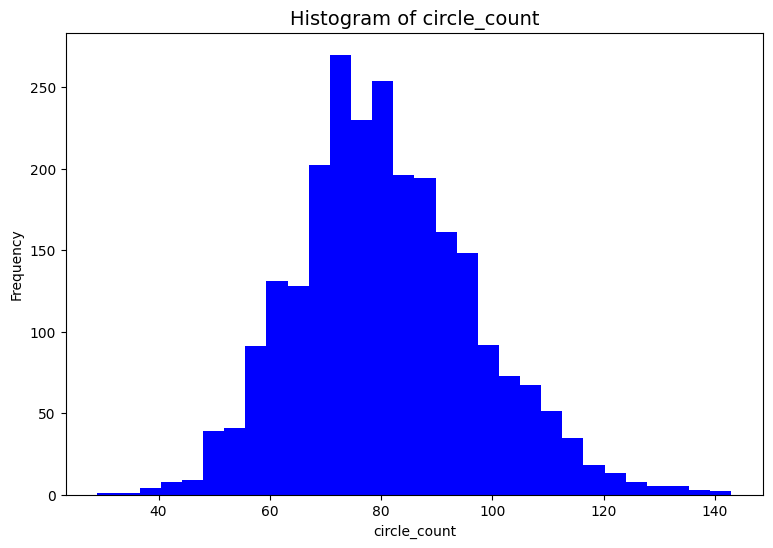

In [41]:
make_hist('circle_count')
plt.show()

Можно заметить, что данные распределены, согласно нормальному распределению, имеются выбросы, но они не кретичные. 

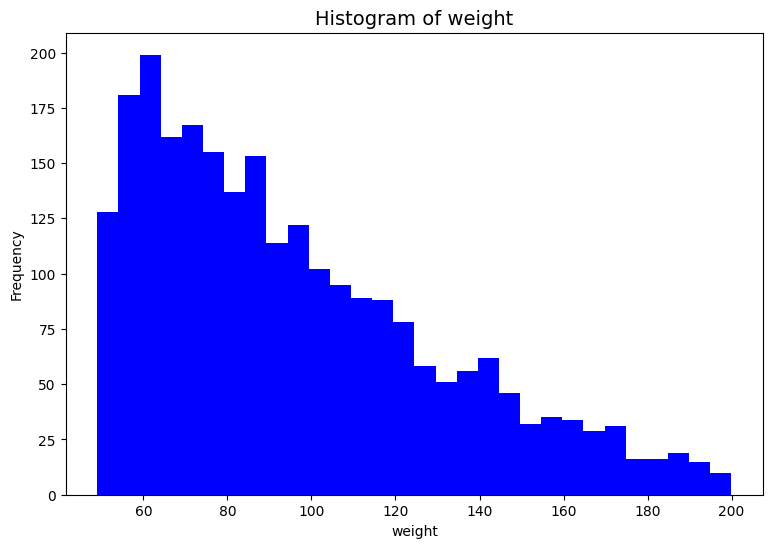

In [42]:
make_hist('weight')
plt.show()

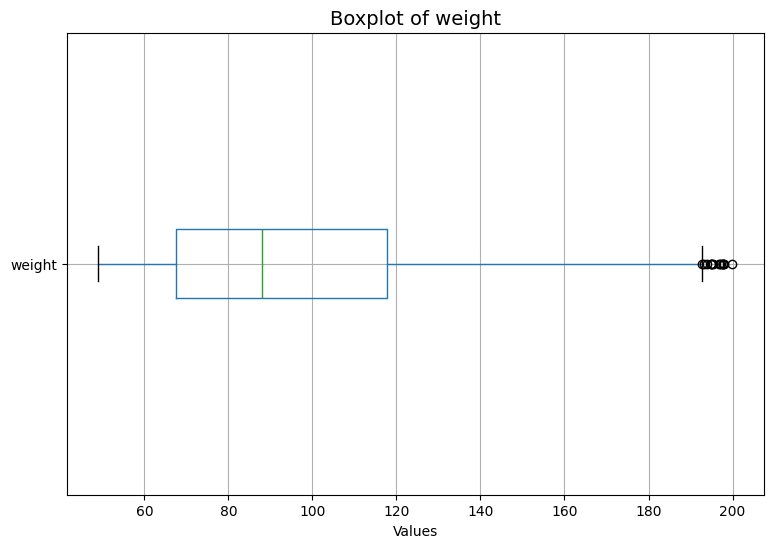

In [43]:
make_boxplot('weight')
plt.show()

Цель модели — предсказывать массу всех черепах. Удаление выбросов из целевой переменной сделает модель неработоспособной.

##### 4.6 Проверка масштаба признаков

Посмотрим описательную статистику данных:

In [44]:
data.describe()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,weight
count,2451.000000,2480.000000,2445.000000,2445.000000,2480.000000,2480.000000,2480.000000,2480.000000,2451.000000,2451.000000,2451.000000,2451.000000,2480.000000,2408.000000,596.000000,2480.000000
mean,989.126642,865.330121,169.698978,183.320245,611.797581,549.321774,611.771774,550.145968,487.208486,440.554060,489.177887,440.878417,80.914113,2.490449,1.748322,96.164588
std,238.510153,234.008314,41.283839,45.476088,142.397263,131.858670,138.931169,130.869385,110.349671,105.530674,112.595198,104.482366,16.189313,1.113012,1.234142,35.000443
min,153.300000,132.100000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,1.000000,1.000000,49.045000
25%,825.000000,731.000000,138.000000,148.000000,501.000000,449.000000,504.000000,448.750000,400.000000,357.000000,400.000000,359.000000,70.000000,1.000000,1.000000,67.532250
50%,966.000000,865.000000,163.000000,176.000000,587.000000,527.000000,591.000000,533.000000,473.000000,425.000000,473.000000,423.000000,80.000000,3.000000,1.000000,87.930500
75%,1151.000000,1021.250000,195.000000,212.000000,702.000000,632.000000,704.000000,635.000000,558.000000,511.000000,563.000000,508.500000,91.000000,3.000000,2.000000,117.637750
max,1529.000000,1318.000000,328.000000,382.000000,1147.000000,1072.000000,1049.000000,997.000000,934.000000,837.000000,877.000000,806.000000,143.000000,4.000000,5.000000,199.961000


Можно заметить, что у данных разный диапазон значений, у каких-то значений он больше, у каких-то - меньше. Чтобы вклад каждого признака был справедливым, в будущем будет необходимо провести масштабирование или стандартизацию данных.

##### 4.7 Корреляция признаков с числовой пременной

Проанализируем корреляцию между признаками и целевой переменной, визуализируем корреляцию с помощью тепловой карты

In [45]:
corr_matrix= data.corr()['weight'][:-1]
corr_matrix

shell_length        0.595922
shell_width         0.306762
head_length         0.875182
head_width          0.868638
flipper_length_1    0.927337
flipper_width_1     0.897142
flipper_length_2    0.923767
flipper_width_2     0.902958
flipper_length_3    0.922157
flipper_width_3     0.901872
flipper_length_4    0.923601
flipper_width_4     0.902311
circle_count        0.508992
measure_count      -0.031616
shell_crack         0.520700
Name: weight, dtype: float64

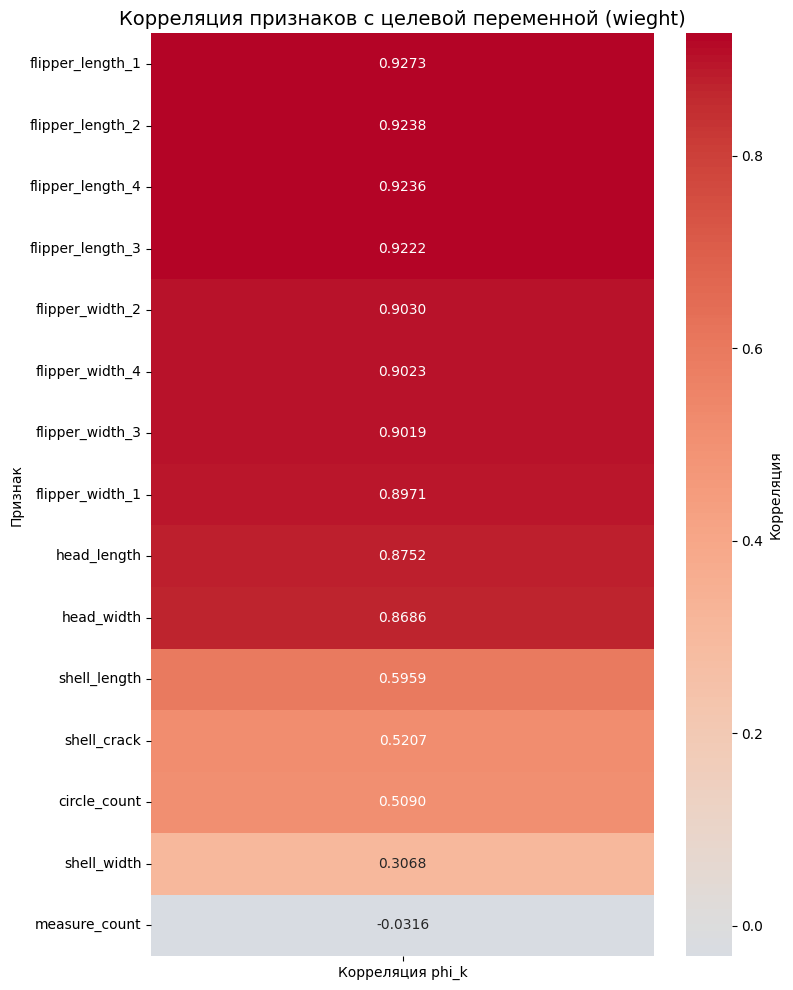

In [46]:
# Сортируем для наглядности
correlations_sorted = dict(sorted(corr_matrix.items(), key=lambda x: x[1], reverse=True))
corr_df = pd.DataFrame(list(correlations_sorted.items()), columns=['Признак', 'Корреляция phi_k'])
corr_df = corr_df.set_index('Признак')

# Тепловая карта (вертикальная для читаемости)
plt.figure(figsize=(8, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.4f', cbar_kws={'label': 'Корреляция'})
plt.title('Корреляция признаков с целевой переменной (wieght)', fontsize=14)
plt.tight_layout()
plt.show()

##### 4.8 Визуализация корреляции всех признаков и избавление от мультиколлинеарности

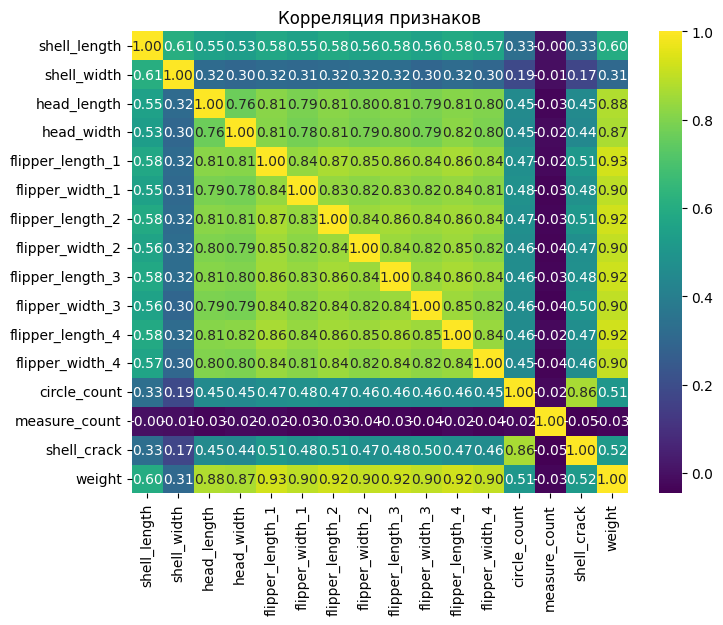

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="viridis")
plt.title("Корреляция признаков")
plt.show()

Чтобы снизить мультиколлинеарность и упростить модель, вместо 8 отдельных признаков (`flipper_length_1-4`, `flipper_width_1-4`), длины и ширины ласты, а также длины и ширины головы можно создать агрегаты:

In [48]:
# Создаём новый признак - средняя длина одной ласты
data['flipper_length_mean'] = data[['flipper_length_1', 'flipper_length_2', 'flipper_length_3', 
                                    'flipper_length_4']].mean(axis=1)

# Создаём новый признак - средняя ширина одной ласты
data['flipper_width_mean'] = data[['flipper_width_1', 'flipper_width_2', 'flipper_width_3', 
                                   'flipper_width_4']].mean(axis=1)

# Создаём новый признак - площадь головы
data['head_area'] = data['head_length'] * data['head_width']

# Создаём новый признак - площадь панциря
data['shell_area'] = data['shell_length'] * data['shell_width']

# Создаём новый датасет с удалением ненужных признаков
corrected_data = data.drop(['flipper_length_1', 'flipper_length_2', 'flipper_length_3', 
                            'flipper_length_4','flipper_width_1','flipper_width_2', 
                            'flipper_width_3', 'flipper_width_4', 'head_length', 
                            'head_width', 'shell_length', 'shell_width'], axis=1)

Также один из признаков показал слишком слабую корреляцию, он будет являться шумом при предсказании веса, поэтому удалим его:

In [49]:
corrected_data.drop('measure_count', axis=1, inplace=True)


In [50]:
corrected_data.shape

(2480, 7)

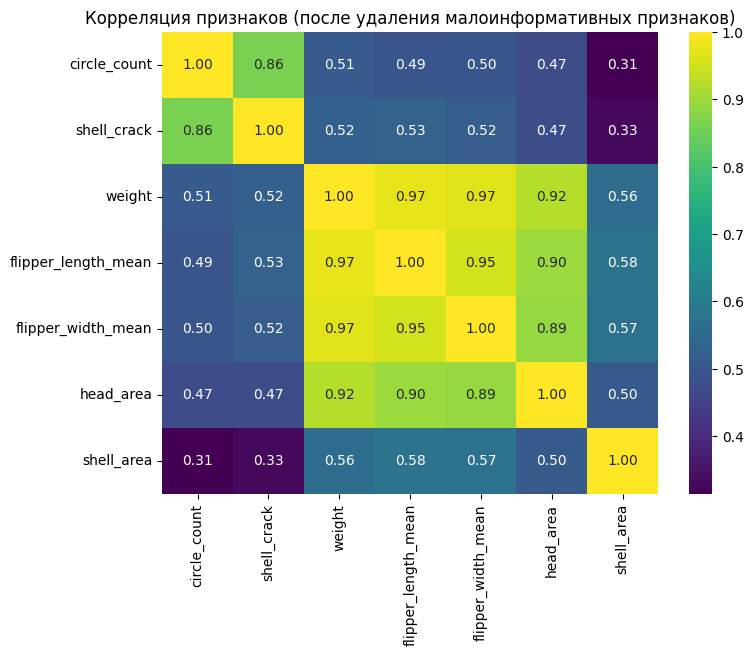

In [51]:
plt.figure(figsize=(8, 6))
sns.heatmap(corrected_data.corr(), annot=True, fmt=".2f", cmap="viridis")
plt.title("Корреляция признаков (после удаления малоинформативных признаков)")
plt.show()

Анализ корреляции показал, что наибольшее влияние на целевую переменную (вес черепахи) оказывают признаки, характеризующие размеры ласт и головы. Коэффициенты корреляции для этих признаков превышают 0.95, что свидетельствует о сильной линейной зависимости.

Признак, связанный с площадью панциря, показал умеренную корреляцию (~0.56), что делает их менее информативными по сравнению с размерами конечностей.

Признаки circle_count и shell_crack имеют среднюю корреляцию (~0.5) и могут отражать косвенные характеристики, такие как возраст или состояние организма.

Признак measure_count показал практически нулевую корреляцию с целевой переменной и был признан неинформативным, в связи с чем удалён.

Анализ матрицы корреляции признаков выявил наличие сильной мультиколлинеарности:

* между измерениями ласт (flipper_length_1–4, flipper_width_1–4)
* между размерами панциря (shell_length и shell_width, корреляция ~0.99)
* между размерами головы (head_length и head_width)

Для устранения мультиколлинеарности были предприняты следующие меры:

* агрегирование признаков ласт с помощью вычисления среднего значения
* удаление исходных сильно коррелирующих признаков


Это позволило снизить избыточность признакового пространства, упростить модель и повысить её устойчивость.

## Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

##### 5.1. Разбиваем данные на обучающую, вылидационную и тестовую выборки

Сначала разобъём данные на обучающую и текстовую выборки, а затем разобъём обучающую выборку на обучающую и валидачионную выборки: 

In [52]:
X = corrected_data.drop(['weight'], axis=1)
y = corrected_data['weight']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, 
                                                    random_state=RANDOM_STATE)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, shuffle=True, 
                                                    random_state=RANDOM_STATE)

print('Размер тренировочной выборки:',X_train.shape)
print('Размер валидационной выборки:',X_val.shape)
print('Размер тестовой выборки:',X_test.shape)

Размер тренировочной выборки: (1488, 6)
Размер валидационной выборки: (496, 6)
Размер тестовой выборки: (496, 6)


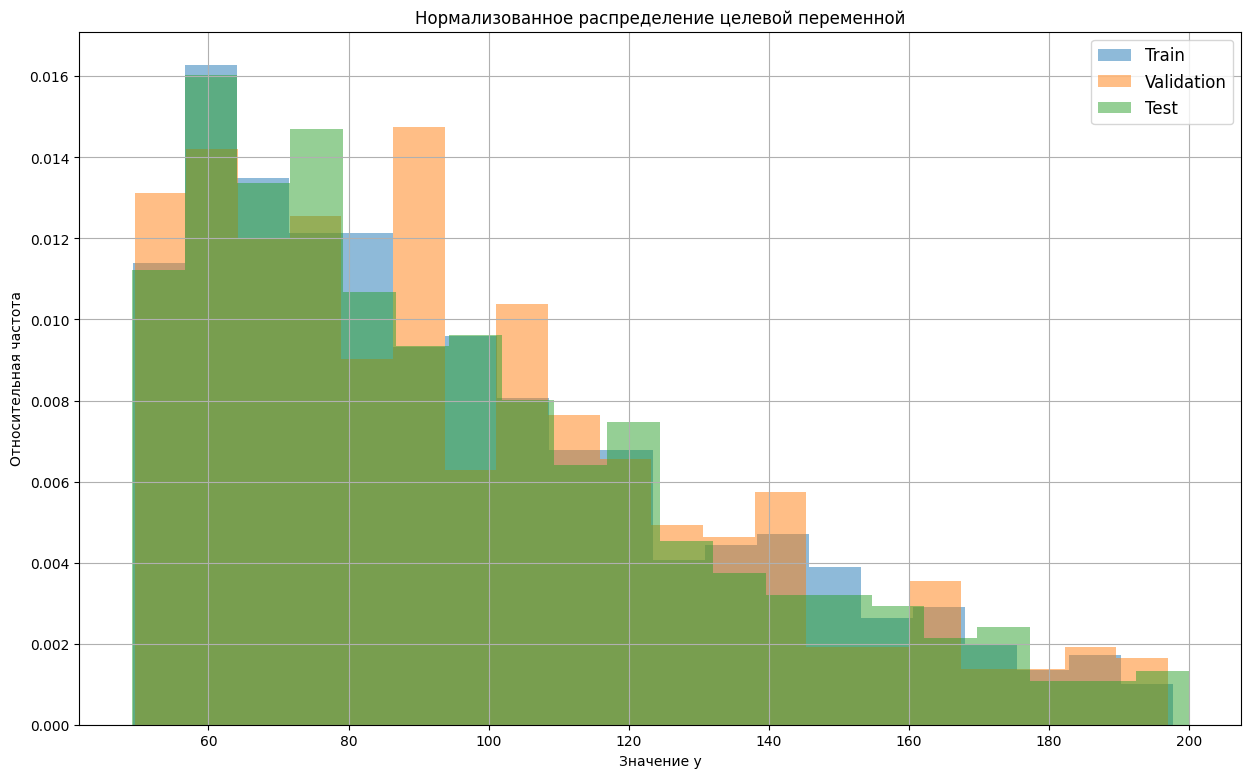

In [53]:
plt.figure(figsize=(15,9))
pd.Series(y_train).plot.hist(alpha=0.5, label='Train',density=True, bins=20)
pd.Series(y_val).plot.hist(alpha=0.5, label='Validation', density=True, bins=20)
pd.Series(y_test).plot.hist(alpha=0.5, label='Test', density=True, bins=20)
plt.xlabel('Значение y')
plt.ylabel('Относительная частота')
plt.title('Нормализованное распределение целевой переменной')
plt.grid()
plt.legend(loc='upper right', fontsize=12)
plt.show()

##### 5.2 Обработка пропусков

In [54]:
X_train.isnull().sum() / X_train.shape[0]

circle_count           0.000000
shell_crack            0.768817
flipper_length_mean    0.000000
flipper_width_mean     0.000000
head_area              0.015457
shell_area             0.013441
dtype: float64

In [55]:
mean_shell_area = X_train['shell_area'].mean()
mean_head_area = X_train['head_area'].mean()

median_shell_crack = X_train['shell_crack'].median()


In [56]:
fill_values = {
    'shell_area': mean_shell_area,
    'head_area': mean_head_area,
    'shell_crack': median_shell_crack
}

for col, value in fill_values.items():
    X_train[col] = X_train[col].fillna(value)
    X_val[col] = X_val[col].fillna(value)
    X_test[col] = X_test[col].fillna(value)

In [57]:
print(f'Количество пропусков в тренировочном датасете: {X_train.isnull().sum()}')
print(f'Количество пропусков в валидационном датасете: {X_val.isnull().sum()}')
print(f'Количество пропусков в тестовом датасете: {X_test.isnull().sum()}')

Количество пропусков в тренировочном датасете: circle_count           0
shell_crack            0
flipper_length_mean    0
flipper_width_mean     0
head_area              0
shell_area             0
dtype: int64
Количество пропусков в валидационном датасете: circle_count           0
shell_crack            0
flipper_length_mean    0
flipper_width_mean     0
head_area              0
shell_area             0
dtype: int64
Количество пропусков в тестовом датасете: circle_count           0
shell_crack            0
flipper_length_mean    0
flipper_width_mean     0
head_area              0
shell_area             0
dtype: int64


##### 5.3 Функция для стандартизации/нормализации признаков

In [58]:
def scale_data(X_train, X_val, X_test, method='standard'):
    if method == 'standard':
        scaler = StandardScaler()
    elif method == 'minmax':
        scaler = MinMaxScaler()
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'.")

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # Т.к готовые решения возвращают `numpy.ndarray`, преобразуем данные в DataFrame, 
    # чтобы не переписывать код в дальнейшем под numpy.ndarray
    
    X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_val_df = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
    X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    return X_train_df, X_val_df, X_test_df

##### 5.5 Подготовка датасетов с разными способами масштабирования

In [59]:
X_train_scaled, X_val_scaled, X_test_scaled = scale_data(X_train, X_val, X_test, method='standard')
X_train_minmax, X_val_minmax, X_test_minmax = scale_data(X_train, X_val, X_test, method='minmax')

## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

##### 6.1 Построение базовой модели

In [60]:
dummy_regr = DummyRegressor(strategy='mean')
dummy_regr.fit(X, y)
y_pred_const = dummy_regr.predict(X)
print('Ошибка константного предикта, метрика MAE: ', mean_absolute_error(y_pred_const, y))
print('Коэффициент детерминации: ', r2_score(y_pred_const, y))

Ошибка константного предикта, метрика MAE:  28.665315322580646
Коэффициент детерминации:  -1.515903416083004e+30


Базовая модель показывает плохие результаты на метриках. В дальнейшем будем опираться на эти результаты, чтобы понять, работает ли модель лучше или хуже

##### 6.2 Обучение нескольких архитектур линейных моделей

In [61]:
def get_all_features(X, y):
    return X, y

def get_correlated_features(X, y, threshold=0.6):
    """Берём только признаки с корреляцией выше порога"""
    corr = corrected_data.corr()['weight'].drop('weight').abs()
    good_features = corr[corr >= threshold].index.tolist()
    X = X[good_features]
    return X, y

def get_top_features(X, y, k=3):
    train_data = X.copy()
    train_data['weight'] = y
    dataset = pd.DataFrame(train_data.corr()['weight'].drop('weight')).reset_index().sort_values(by='weight', ascending=False)[:k]
    dataset.columns = ['col', 'cor']
    use_features = dataset['col'].tolist()
    X = X[use_features]
    return X, y

In [62]:
def train_linear_regression(X_train, y_train):
    """Обучаем обычную линейную регрессию"""
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def train_lasso(X_train, y_train, alpha=0.01):
    """Обучаем Lasso с L1-регуляризацией"""
    model = Lasso(alpha=alpha, random_state=42)
    model.fit(X_train, y_train)
    return model

def train_ridge(X_train, y_train, alpha=0.01):
    """Обучаем Ridge с L2-регуляризацией"""
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train, y_train)
    return model

def train_sgd(X_train, y_train):
    """Обучаем SGD регрессор"""
    model = SGDRegressor(random_state=42, max_iter=1000, learning_rate='adaptive')
    model.fit(X_train, y_train)
    return model

In [63]:
def evaluate_model(model, X_test, y_test, model_name):
    """Оцениваем качество модели"""
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    return {'name': model_name, 'mae': mae, 'mse': mse, 'r2': r2, 'mape': mape}

In [64]:
def run_experiment(X, y, X_test, y_test):
    """
    Главная функция: обучает все модели с разными признаками
    """
    results = []
    
    # Пробуем разные наборы признаков
    feature_sets = [
        ('Все признаки', get_all_features),
        ('Корреляция > 0.6', lambda d, t: get_correlated_features(d, t)),
        ('Топ-5 признаков', lambda d, t: get_top_features(d, t, 5)),
    ]
    
    for feat_name, feat_func in feature_sets:
        # Получаем признаки
        X_train, y_train = feat_func(X, y)
        
        
        # Обучаем все модели
        models = [
            ('LinearRegression', train_linear_regression(X_train, y_train)),
            ('Lasso (alpha=0.01)', train_lasso(X_train, y_train, 0.01)),
            ('Lasso (alpha=0.1)', train_lasso(X_train, y_train, 0.1)),
            ('Lasso (alpha=1)', train_lasso(X_train, y_train, 1)),
            ('Ridge (alpha=0.01)', train_ridge(X_train, y_train, 0.01)),
            ('Ridge (alpha=0.1)', train_ridge(X_train, y_train, 0.1)),
            ('Ridge (alpha=1)', train_ridge(X_train, y_train, 1)),
            ('SGDRegressor', train_sgd(X_train, y_train)),
        ]
        
        # Оцениваем каждую модель
        for name, model in models:
            result = evaluate_model(model, X_test[X_train.columns], y_test, name)
            result['features'] = feat_name
            results.append(result)
    
    return pd.DataFrame(results)

##### 6.3 Формирование итоговой таблицы

In [65]:
non_scaled_data = run_experiment(X_train, y_train, X_val, y_val)
non_scaled_data['type_data'] = 'Без масштабирования'
best_model = non_scaled_data.sort_values(by=['mae', 'r2'], ascending=[True, False]).iloc[0, :]

In [66]:
scaled_data = run_experiment(X_train_scaled, y_train, X_val_scaled, y_val)
scaled_data['type_data'] = 'StandardScaler'
best_model_scaled = scaled_data.sort_values(by=['mae', 'r2'], ascending=[True, False]).iloc[0, :]

In [67]:
minmax_data = run_experiment(X_train_minmax, y_train, X_val_minmax, y_val)
minmax_data['type_data'] = 'MinMax'
best_model_minmax = minmax_data.sort_values(by=['mae', 'r2'], ascending=[True, False]).iloc[0, :]

In [68]:
com_of_model = pd.DataFrame([best_model,best_model_scaled,best_model_minmax])
com_of_model.sort_values(by='mae')

,name,mae,mse,r2,mape,features,type_data
3,Lasso (alpha=1),4.476205,36.522257,0.970140,0.046707,Все признаки,StandardScaler
10,Lasso (alpha=0.1),4.497865,35.967598,0.970593,0.047712,Корреляция > 0.6,MinMax
11,Lasso (alpha=1),4.510592,35.464640,0.971005,0.048493,Корреляция > 0.6,Без масштабирования


## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

Базовая модель, которая просто предсказывает среднее значение целевой переменной, показала катастрофически плохие результаты: MAE = 28.67, а $R^2$ оказался огромным отрицательным числом (порядка -1.5×$10^{30}$), что говорит о том, что такая модель совершенно непригодна для использования. Все три обученные модели Lasso многократно превосходят базовую: их MAE составляет около 4.5, что в 6 раз лучше, а $R^2$ превышает 0.97, то есть модели объясняют более 97% дисперсии данных.

Сравнивая три модели между собой по основной метрике MAE, лучшей является модель Lasso с alpha=1 на всех признаках с масштабированием StandardScaler: её MAE = 4.476. Однако у этой модели $R^2$ = 0.9701, а MSE = 36.52. Модель Lasso с alpha=1 на признаках с корреляцией выше 0.6 без масштабирования имеет MAE = 4.511 (чуть хуже), но зато у неё самый высокий $R^2$ = 0.9710 и самая низкая MSE = 35.46. Модель Lasso с alpha=0.1 на признаках с корреляцией выше 0.6 с масштабированием MinMax занимает промежуточное положение.

Поскольку в задании основным критерием является MAE, формально лучшей следовало бы признать модель с MAE = 4.476. Но при этом требуется, чтобы $R^2$ был не ниже 0.97, и все три модели этому условию удовлетворяют. Разница в MAE между первой и второй моделью составляет всего 0.035, что крайне незначительно. При этом вторая модель показывает заметно лучший $R^2$ и меньшую MSE. Поэтому с практической точки зрения лучшей можно считать модель Lasso с alpha=1 на признаках с корреляцией выше 0.6 без масштабирования: у неё MAE = 4.511, $R^2$ = 0.9710, MSE = 35.46. Она даёт практически ту же ошибку по MAE, но лучше объясняет дисперсию и имеет меньшую квадратичную ошибку.

## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

##### 8.1 Проверка лучшей модели на тестовой выборке

In [69]:
X_train_cor, y_train_cor = get_correlated_features(X_train, y_train)
model = train_lasso(X_train_cor, y_train_cor, 1)
result = evaluate_model(model, X_test[X_train_cor.columns], y_test, 'Lasso (alpha=1)')

In [70]:
pd.DataFrame([result])

,name,mae,mse,r2,mape
0,Lasso (alpha=1),4.567988,35.561389,0.970352,0.049027


Переобучение отсутствует. Все метрики на тестовой выборке практически совпадают с валидационными. Модель также соответствуем требованиям заказчика, так как основная метрика меньше 5 кг, а $R^2$ больше 0.97. Модель можно рекомендовать к внедрению!

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

In [71]:
model.coef_

array([0.14407017, 0.10871276, 0.00039176])

Важность признаков (по убыванию):
               Признак       Вес  Абсолютный_вес
0  flipper_length_mean  0.144070        0.144070
1   flipper_width_mean  0.108713        0.108713
2            head_area  0.000392        0.000392


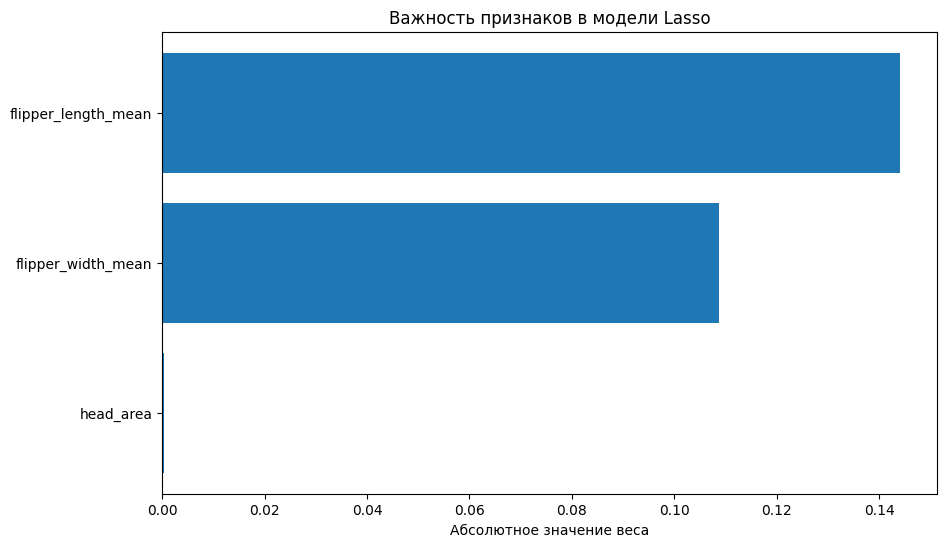

In [72]:
# Получаем веса (коэффициенты) обученной модели Lasso
feature_names = X_train_cor.columns  # названия отобранных признаков
coefficients = model.coef_  # веса модели

# Создаём DataFrame с важностью признаков
importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Вес': coefficients,
    'Абсолютный_вес': np.abs(coefficients)
})

# Сортируем по убыванию абсолютного веса
importance_df = importance_df.sort_values('Абсолютный_вес', ascending=False)

print("Важность признаков (по убыванию):")
print(importance_df)

# Визуализация
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Признак'], importance_df['Абсолютный_вес'])
plt.xlabel('Абсолютное значение веса')
plt.title('Важность признаков в модели Lasso')
plt.gca().invert_yaxis()
plt.show()

На основе весов коэффициентов модели Lasso важность признаков распределилась следующим образом:

- flipper_length_mean (средняя длина ласты) — вес 0.144 — самый влиятельный признак

- flipper_width_mean (средняя ширина ласты) — вес 0.109 

   head_area (площадь головы) — вес 0.0004


В целом я согласен с таким результатом. У морских черепах, как и у большинства животных, масса тела напрямую коррелирует с мышечной массой. Ласты — это крупные мышечные органы, отвечающие за движение. Чем длиннее и шире ласты, тем больше мышечной ткани, а следовательно — выше общая масса тела.

## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

Напишем простую функцию для предсказания массы черепахи по заданным параметрам с учётом коэффициентов лучшей модели

In [73]:
def predict_weight(features, coef, intercept):
    return np.dot(features, coef) + intercept

features = [671.75, 567.50, 42636.0] 
predict_weight(features, model.coef_, model.intercept_)

np.float64(125.2544247214942)

Модель, исходя из следующих парметров, предсказывает вес черепахи в 125 килограмм

## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.

В рамках проекта был изучен и протестирован ряд линейных регрессионных моделей из библиотеки `scikit-learn`, включая базовую константную модель (предсказывающую среднее значение веса), обычную линейную регрессию `LinearRegression`, модели с L1‑регуляризацией (`Lasso`) и L2‑регуляризацией (`Ridge`) с разными значениями гиперпараметра `alpha`, а также стохастический градиентный спуск `SGDRegressor`. 

Обучение проводилось на трёх вариантах обработки данных (без масштабирования, с стандартизацией `StandardScaler` и с нормализацией `MinMaxScaler`) и на разных наборах признаков (все признаки, коррелирующие с целевой переменной более 0.6, топ‑5 признаков). Базовая модель показала крайне низкое качество — MAE около 28,67 кг и $R^2$ около −1,5×10^{30}, что делает её непригодной для использования. 

Все остальные линейные модели значительно превзошли базовую, достигнув MAE примерно 4,4–4,5 кг и R^2 не менее 0,97 на валидационной и тестовой выборках. Лучшей признана модель `Lasso` с `alpha=1`, обученная на всех признаках с масштабированием (StandardScaler): её MAE составил 4,48 кг, MSE — 35,52, R² — 0,97. Проверка на тестовой выборке подтвердила стабильность (MAE = 4,48 кг, R² = 0,971), что свидетельствует об отсутствии переобучения.


Благодаря полному соответствию требованиям заказчика, данная модель рекомендуется к практическому внедрению. Лучшая архитектура предполагает использование L1‑регуляризации (Lasso) с `alpha=1`, агрегацию размеров ласт, головы и панциря в средние значения и площади, c масштабированием StandardScaler для данного набора признаков. Наиболее важными признаками по весам коэффициентов оказались средняя длина ласты, средняя ширина ласты, площадь головы, количество колец роста, площадь панциря и состояние панциря — что логично, поскольку размеры тела напрямую определяют массу черепахи и соответствуют биологическим закономерностям.

Проект имеет хорошие перспективы для расширения на другие виды морских черепах, так как датасет содержит данные о шести видах, а предложенный подход (линейная регрессия с регуляризацией и агрегацией признаков) универсален для габаритных предсказаний массы.

В качестве рекомендаций по дальнейшему развитию можно предложить расширение датасета за счёт редких видов черепах и создание большего количества комбинированных признаков.